<a href="https://colab.research.google.com/github/muhammetalicvs-prog/flyrank-ml/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [24]:
# Section 1 — Build the ranked content action queue

from pathlib import Path
import os
import numpy as np
import pandas as pd

from IPython.display import display

REPO_URL = "https://github.com/muhammetalicvs-prog/flyrank-ml.git"
REPO_DIR = Path("/content/flyrank-ml")

# Clone the repository when running in a fresh Colab session.
if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repository already exists:", REPO_DIR)

os.chdir(REPO_DIR)

candidate_paths = [
    Path("data/raw/content_refresh_anonymized.csv"),
    Path("/content/flyrank-ml/data/raw/content_refresh_anonymized.csv"),
]

DATA_PATH = next(
    (path for path in candidate_paths if path.exists()),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "The anonymized starter dataset could not be found."
    )

df = pd.read_csv(DATA_PATH)

required_columns = {
    "content_id",
    "client_id",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
    "content_type",
    "age_tier",
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {sorted(missing_columns)}"
    )

print("Dataset path:", DATA_PATH.resolve())
print(f"Rows loaded: {len(df):,}")
print(f"Columns loaded: {df.shape[1]}")

Repository already exists: /content/flyrank-ml
Dataset path: /content/flyrank-ml/data/raw/content_refresh_anonymized.csv
Rows loaded: 30,000
Columns loaded: 44


In [25]:
# Recreate the validated Week-4 baseline score.

queue = df.copy()

# The FlyRank dataset stores CTR as a percentage multiplied by 100.
# For example, 0.20 means 0.20%, not 20%.
queue["visibility_score"] = np.clip(
    np.log1p(queue["impressions_90d"].clip(lower=0))
    / np.log1p(10000),
    0,
    1,
)

queue["position_score"] = np.clip(
    (20 - queue["avg_position"]) / 20,
    0,
    1,
)

queue["low_ctr_score"] = np.clip(
    (0.20 - queue["ctr"]) / 0.20,
    0,
    1,
)

queue["action_score"] = (
    100
    * (
        0.40 * queue["visibility_score"]
        + 0.30 * queue["position_score"]
        + 0.30 * queue["low_ctr_score"]
    )
)

# Apply the same eligibility conditions used in the validated baseline.
queue["eligible_for_review"] = (
    (queue["impressions_90d"] >= 100)
    & (queue["avg_position"] > 0)
    & (queue["avg_position"] <= 20)
    & queue["ctr"].notna()
    & (queue["ctr"] < 0.20)
)

ranked_queue = (
    queue.loc[queue["eligible_for_review"]]
    .sort_values(
        ["action_score", "impressions_90d"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

ranked_queue.insert(
    0,
    "rank",
    np.arange(1, len(ranked_queue) + 1),
)

print(f"Eligible review candidates: {len(ranked_queue):,}")
print(
    "Eligible share:",
    f"{len(ranked_queue) / len(queue):.2%}",
)

Eligible review candidates: 7,497
Eligible share: 24.99%


In [26]:
# Assign practical reason codes, content archetypes, and review actions.

def assign_reason_code(row):
    if (
        row["impressions_90d"] >= 5000
        and row["avg_position"] <= 10
        and row["ctr"] < 0.10
    ):
        return "HIGH_VISIBILITY_LOW_CTR"

    if (
        row["avg_position"] <= 5
        and row["ctr"] < 0.20
    ):
        return "TOP_POSITION_CTR_GAP"

    # 90 günden eski ve hâlâ görünür olan içerikleri
    # manuel güncellik kontrolüne ayırır.
    if (
        row["days_since_last_update"] >= 90
        and row["impressions_90d"] >= 500
    ):
        return "AGING_VISIBLE_CONTENT"

    if (
        row["engagement_rate"] < 20
        and row["impressions_90d"] >= 500
    ):
        return "VISIBLE_LOW_ENGAGEMENT"

    return "GENERAL_CTR_OPPORTUNITY"


def assign_archetype(row):
    archetype_map = {
        "HIGH_VISIBILITY_LOW_CTR":
            "Visible page with weak search click-through",

        "TOP_POSITION_CTR_GAP":
            "High-ranking page with an unusually weak CTR",

        "AGING_VISIBLE_CONTENT":
            "Older page that still receives search visibility",

        "VISIBLE_LOW_ENGAGEMENT":
            "Visible page with weak on-page engagement",

        "GENERAL_CTR_OPPORTUNITY":
            "Moderate search opportunity requiring diagnosis",
    }

    return archetype_map[row["reason_code"]]


def assign_action(row):
    action_map = {
        "HIGH_VISIBILITY_LOW_CTR":
            "Review title and meta description against search intent",

        "TOP_POSITION_CTR_GAP":
            "Inspect SERP snippet, title clarity, and competing results",

        "AGING_VISIBLE_CONTENT":
            "Check factual freshness and whether a targeted refresh is justified",

        "VISIBLE_LOW_ENGAGEMENT":
            "Review intent match, introduction, structure, and internal links",

        "GENERAL_CTR_OPPORTUNITY":
            "Perform a manual content and search-intent review",
    }

    return action_map[row["reason_code"]]


ranked_queue["reason_code"] = ranked_queue.apply(
    assign_reason_code,
    axis=1,
)

ranked_queue["content_archetype"] = ranked_queue.apply(
    assign_archetype,
    axis=1,
)

ranked_queue["recommended_action"] = ranked_queue.apply(
    assign_action,
    axis=1,
)

ranked_queue["review_priority"] = pd.cut(
    ranked_queue["rank"],
    bins=[
        0,
        50,
        200,
        1000,
        np.inf,
    ],
    labels=[
        "P1 — Review first",
        "P2 — Review next",
        "P3 — Review when capacity allows",
        "P4 — Backlog",
    ],
)

display_columns = [
    "rank",
    "content_id",
    "client_id",
    "action_score",
    "review_priority",
    "reason_code",
    "content_archetype",
    "recommended_action",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
]

display(
    ranked_queue[display_columns]
    .head(20)
    .round(
        {
            "action_score": 2,
            "ctr": 4,
            "avg_position": 2,
            "engagement_rate": 2,
        }
    )
)

,rank,content_id,client_id,action_score,review_priority,reason_code,content_archetype,recommended_action,impressions_90d,clicks_90d,ctr,avg_position,engagement_rate,days_since_last_update
0,1,content_4a6607efcb46,client_6208ef0f77,95.20,P1 — Review first,HIGH_VISIBILITY_LOW_CTR,Visible page with weak search click-through,Review title and meta description against sear...,128068,17,0.01,2.2,2.30,104
1,2,content_134631e65b9e,client_6208ef0f77,94.20,P1 — Review first,TOP_POSITION_CTR_GAP,High-ranking page with an unusually weak CTR,"Inspect SERP snippet, title clarity, and compe...",4417,0,0.00,1.5,0.00,20
2,3,content_c82bc0c24241,client_f369cb89fc,93.55,P1 — Review first,HIGH_VISIBILITY_LOW_CTR,Visible page with weak search click-through,Review title and meta description against sear...,13676,0,0.00,4.3,0.00,8
3,4,content_cbdf5a78dcd0,client_19581e27de,93.40,P1 — Review first,HIGH_VISIBILITY_LOW_CTR,Visible page with weak search click-through,Review title and meta description against sear...,14830,3,0.02,2.4,0.00,104
4,5,content_c90bfc85694f,client_b4944c6ff0,93.19,P1 — Review first,TOP_POSITION_CTR_GAP,High-ranking page with an unusually weak CTR,"Inspect SERP snippet, title clarity, and compe...",3047,0,0.00,1.1,0.00,20
5,6,content_998f6f88784c,client_f74efabef1,93.10,P1 — Review first,HIGH_VISIBILITY_LOW_CTR,Visible page with weak search click-through,Review title and meta description against sear...,12053,3,0.02,2.6,37.50,8
6,7,content_339b357d04c7,client_bbb965ab0c,92.95,P1 — Review first,HIGH_VISIBILITY_LOW_CTR,Visible page with weak search click-through,Review title and meta description against sear...,46879,7,0.01,3.7,0.00,15
7,8,content_50dfd64f9e8e,client_19581e27de,92.88,P1 — Review first,TOP_POSITION_CTR_GAP,High-ranking page with an unusually weak CTR,"Inspect SERP snippet, title clarity, and compe...",4446,0,0.00,2.4,0.00,104
8,9,content_971e2a5035bc,client_6208ef0f77,92.88,P1 — Review first,HIGH_VISIBILITY_LOW_CTR,Visible page with weak search click-through,Review title and meta description against sear...,9179,1,0.01,3.5,0.00,104
9,10,content_b7bd590fe572,client_19581e27de,92.65,P1 — Review first,HIGH_VISIBILITY_LOW_CTR,Visible page with weak search click-through,Review title and meta description against sear...,12331,3,0.02,2.9,0.00,104


### Ranked action playbook

The playbook converts the validated Week-4 baseline into a ranked queue for human content review.

The queue prioritizes content items that already receive meaningful search visibility but show a combination of low click-through rate and useful search position. The score combines three transparent components:

- search visibility, weighted at 40%;
- search position opportunity, weighted at 30%;
- low-CTR opportunity, weighted at 30%.

The queue is not a list of pages that should automatically be edited. It is a decision-support list showing which anonymized content records appear worth reviewing first.

Each candidate receives a reason code, a plain-language content archetype, and a recommended review action. The reason codes make the ranking easier to inspect and help reviewers understand why an item entered the queue.

The highest-priority archetypes are:

| Reason code | Content archetype | Suggested human action |
|---|---|---|
| `HIGH_VISIBILITY_LOW_CTR` | Visible page with weak search click-through | Review the title and meta description against search intent |
| `TOP_POSITION_CTR_GAP` | High-ranking page with an unusually weak CTR | Inspect the search snippet, title clarity, and competing results |
| `AGING_VISIBLE_CONTENT` | Older page that still receives search visibility | Check factual freshness before deciding whether to refresh |
| `VISIBLE_LOW_ENGAGEMENT` | Visible page with weak on-page engagement | Review intent match, introduction, structure, and internal links |
| `GENERAL_CTR_OPPORTUNITY` | Moderate opportunity requiring diagnosis | Perform a broader manual content review |

In the earlier grouped evaluation, the Week-4 baseline achieved a Precision@50 of 0.88 on the held-out test clients, compared with 0.64 for Logistic Regression and 0.58 for Random Forest. The test-set decline base rate was 0.511.

These measurements support using the baseline for this small review queue. They do not show that applying the recommended action will improve traffic, rankings, clicks, or business outcomes.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [27]:
# Section 2 — Summarize the intended operating scope of the playbook.

reason_summary = (
    ranked_queue
    .groupby(
        [
            "reason_code",
            "content_archetype",
            "recommended_action",
        ],
        observed=True,
    )
    .agg(
        candidate_count=("content_id", "size"),
        median_action_score=("action_score", "median"),
        median_impressions=("impressions_90d", "median"),
        median_ctr=("ctr", "median"),
        median_position=("avg_position", "median"),
        median_days_since_update=("days_since_last_update", "median"),
    )
    .reset_index()
    .sort_values(
        ["candidate_count", "median_action_score"],
        ascending=[False, False],
    )
)

reason_summary["queue_share"] = (
    reason_summary["candidate_count"] / len(ranked_queue)
)

display(
    reason_summary.round(
        {
            "median_action_score": 2,
            "median_impressions": 0,
            "median_ctr": 4,
            "median_position": 2,
            "median_days_since_update": 0,
            "queue_share": 4,
        }
    )
)

,reason_code,content_archetype,recommended_action,candidate_count,median_action_score,median_impressions,median_ctr,median_position,median_days_since_update,queue_share
4,VISIBLE_LOW_ENGAGEMENT,Visible page with weak on-page engagement,"Review intent match, introduction, structure, ...",2820,63.49,2228.0,0.11,10.6,20.0,0.3762
1,GENERAL_CTR_OPPORTUNITY,Moderate search opportunity requiring diagnosis,Perform a manual content and search-intent review,1778,66.91,243.0,0.00,10.8,20.0,0.2372
0,AGING_VISIBLE_CONTENT,Older page that still receives search visibility,Check factual freshness and whether a targeted...,1591,64.76,2079.0,0.10,10.4,104.0,0.2122
3,TOP_POSITION_CTR_GAP,High-ranking page with an unusually weak CTR,"Inspect SERP snippet, title clarity, and compe...",809,75.77,1508.0,0.08,3.8,22.0,0.1079
2,HIGH_VISIBILITY_LOW_CTR,Visible page with weak search click-through,Review title and meta description against sear...,499,80.27,12076.0,0.06,7.0,22.0,0.0666


In [28]:
# Review-capacity scenarios.

review_capacity = pd.DataFrame(
    {
        "review_scenario": [
            "Small weekly review",
            "Medium weekly review",
            "Expanded review cycle",
        ],
        "items_reviewed": [
            20,
            50,
            200,
        ],
        "estimated_minutes_per_item": [
            15,
            15,
            15,
        ],
    }
)

review_capacity["estimated_total_hours"] = (
    review_capacity["items_reviewed"]
    * review_capacity["estimated_minutes_per_item"]
    / 60
)

review_capacity["share_of_full_queue"] = (
    review_capacity["items_reviewed"] / len(ranked_queue)
)

display(
    review_capacity.round(
        {
            "estimated_total_hours": 1,
            "share_of_full_queue": 4,
        }
    )
)

,review_scenario,items_reviewed,estimated_minutes_per_item,estimated_total_hours,share_of_full_queue
0,Small weekly review,20,15,5.0,0.0027
1,Medium weekly review,50,15,12.5,0.0067
2,Expanded review cycle,200,15,50.0,0.0267


### Intended use

This playbook is intended to support a content analyst, SEO specialist, or editor who must decide which content records should be investigated first.

The ranked queue should be used as follows:

1. Select a review batch that matches the available human-review capacity, such as the first 20 or first 50 records.
2. Read the reason code and recommended action for each record.
3. Inspect the actual page, search result, query context, content purpose, and business importance.
4. Decide whether an edit, refresh, deeper investigation, or no action is appropriate.
5. Record the reviewer’s decision and, when an action is taken, measure the result separately.

The ranking is most useful as a prioritization mechanism. It reduces the number of records that a reviewer must inspect before finding plausible opportunities. It does not replace editorial judgment.

### Decay and refresh insight

Content age should be treated as a diagnostic signal rather than proof that a page requires a refresh.

An older page that still receives impressions may be a useful refresh candidate because users continue to encounter it. However, age alone does not show that the information is outdated or that changing the page will improve performance.

The `AGING_VISIBLE_CONTENT` reason code therefore means:

> This page is old enough and visible enough to justify a factual freshness check.

It does not mean:

> This page must be rewritten because old content always performs worse.

A reviewer should check publication context, factual accuracy, search intent, historical value, and whether the topic genuinely changes over time before recommending an update.

### Operational limits

The full queue contains thousands of candidates and should not be interpreted as a requirement to review every record.

A practical workflow should use small batches based on available capacity. At an assumed 15 minutes per item, reviewing 50 records would require approximately 12.5 analyst hours. The queue should therefore be treated as a backlog from which manageable review batches are selected.

The score is relative within the available dataset. It is not a probability of success, expected traffic gain, financial value, or confidence score.

The score also does not account for several important factors, including:

* the exact search queries that produced impressions;
* changes in the search results page;
* brand and legal requirements;
* conversion value;
* content production cost;
* page ownership;
* strategic business importance;
* seasonality;
* indexation or technical SEO problems;
* whether the content is intentionally historical;
* whether another page targets the same search intent.

### Evidence limits

The prioritization rule was evaluated offline on held-out clients. The Week-4 baseline achieved a Precision@50 of 0.88 in that evaluation, while the test-set positive base rate was 0.511.

This result indicates that positive labelled cases were concentrated near the top of the test ranking. It does not establish that editing those pages will cause additional clicks, rankings, conversions, revenue, or other business improvements.

There was no production deployment, randomized experiment, or causal impact evaluation. Any benefit from acting on the queue must therefore be tested and measured separately.

### Non-production status

This notebook is a practical research prototype rather than a production decision system.

It does not include:

* live data ingestion;
* authentication or access controls;
* automated content changes;
* workflow integration;
* alert delivery;
* service-level guarantees;
* production drift detection;
* rollback mechanisms;
* causal performance measurement.

Its role is to create a reproducible, human-reviewed queue that can support the recommendations section of the research paper.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [29]:
# Section 3 — Define human-review rules.

human_review_rules = pd.DataFrame(
    [
        {
            "review_step": 1,
            "rule": "Confirm page identity and ownership",
            "reviewer_check": (
                "Open the actual page and confirm that the content record "
                "belongs to the expected client, site, and content type."
            ),
            "decision": (
                "Continue only when the page can be identified safely."
            ),
        },
        {
            "review_step": 2,
            "rule": "Inspect search intent and query context",
            "reviewer_check": (
                "Review the queries, search-result context, competing pages, "
                "and whether the page matches the likely user need."
            ),
            "decision": (
                "Do not recommend title or content changes from aggregate CTR alone."
            ),
        },
        {
            "review_step": 3,
            "rule": "Check factual and editorial risk",
            "reviewer_check": (
                "Check whether the page contains legal, medical, financial, "
                "regulated, contractual, or brand-sensitive claims."
            ),
            "decision": (
                "Escalate sensitive content to an authorized subject-matter reviewer."
            ),
        },
        {
            "review_step": 4,
            "rule": "Check technical explanations first",
            "reviewer_check": (
                "Check indexation, canonical tags, redirects, page availability, "
                "tracking quality, and other technical causes."
            ),
            "decision": (
                "Do not rewrite content when a technical issue better explains the signal."
            ),
        },
        {
            "review_step": 5,
            "rule": "Assess refresh necessity",
            "reviewer_check": (
                "For older visible content, verify whether facts, examples, dates, "
                "screenshots, links, or recommendations are genuinely outdated."
            ),
            "decision": (
                "Keep accurate evergreen or intentionally historical content unchanged."
            ),
        },
        {
            "review_step": 6,
            "rule": "Estimate effort and value",
            "reviewer_check": (
                "Compare likely review or editing effort with visibility, strategic "
                "importance, business value, and available team capacity."
            ),
            "decision": (
                "Defer low-value or high-cost changes even when the action score is high."
            ),
        },
        {
            "review_step": 7,
            "rule": "Record the human decision",
            "reviewer_check": (
                "Record approve, reject, defer, investigate, or no-change together "
                "with a short rationale."
            ),
            "decision": (
                "No content action should occur without a documented reviewer decision."
            ),
        },
    ]
)

display(human_review_rules)

,review_step,rule,reviewer_check,decision
0,1,Confirm page identity and ownership,Open the actual page and confirm that the cont...,Continue only when the page can be identified ...
1,2,Inspect search intent and query context,"Review the queries, search-result context, com...",Do not recommend title or content changes from...
2,3,Check factual and editorial risk,"Check whether the page contains legal, medical...",Escalate sensitive content to an authorized su...
3,4,Check technical explanations first,"Check indexation, canonical tags, redirects, p...",Do not rewrite content when a technical issue ...
4,5,Assess refresh necessity,"For older visible content, verify whether fact...",Keep accurate evergreen or intentionally histo...
5,6,Estimate effort and value,Compare likely review or editing effort with v...,Defer low-value or high-cost changes even when...
6,7,Record the human decision,"Record approve, reject, defer, investigate, or...",No content action should occur without a docum...


In [30]:
# Define actions that must not be automated.

no_go_cases = pd.DataFrame(
    [
        {
            "no_go_case": "Automatic publishing or rewriting",
            "why_not": (
                "The score does not verify factual accuracy, search intent, "
                "brand voice, or editorial quality."
            ),
            "required_handling": (
                "Require human approval before any page change."
            ),
        },
        {
            "no_go_case": "Automatic title or meta replacement",
            "why_not": (
                "Low aggregate CTR may reflect query mix, SERP features, "
                "brand demand, seasonality, or measurement noise."
            ),
            "required_handling": (
                "Inspect queries and competing search results before changing metadata."
            ),
        },
        {
            "no_go_case": "Automatic deletion, deindexing, or redirects",
            "why_not": (
                "The queue does not measure backlinks, conversions, historical value, "
                "legal retention needs, or page dependencies."
            ),
            "required_handling": (
                "Require technical, editorial, and business-owner review."
            ),
        },
        {
            "no_go_case": "Automatic conclusions from content age",
            "why_not": (
                "Older content may remain accurate, evergreen, intentionally historical, "
                "or valuable without modification."
            ),
            "required_handling": (
                "Use age only as a trigger for a factual freshness check."
            ),
        },
        {
            "no_go_case": "Automatic action on sensitive content",
            "why_not": (
                "Medical, legal, financial, safety, regulated, or contractual material "
                "requires qualified review."
            ),
            "required_handling": (
                "Route to an authorized subject-matter expert."
            ),
        },
        {
            "no_go_case": "Automatic business-value claims",
            "why_not": (
                "The offline ranking does not estimate incremental revenue, conversions, "
                "traffic lift, or causal impact."
            ),
            "required_handling": (
                "Treat value estimates as hypotheses and measure outcomes separately."
            ),
        },
        {
            "no_go_case": "Cross-client comparison without context",
            "why_not": (
                "Clients may differ in industry, audience, content strategy, "
                "traffic scale, and measurement quality."
            ),
            "required_handling": (
                "Review rankings within the relevant client and business context."
            ),
        },
    ]
)

display(no_go_cases)

,no_go_case,why_not,required_handling
0,Automatic publishing or rewriting,"The score does not verify factual accuracy, se...",Require human approval before any page change.
1,Automatic title or meta replacement,"Low aggregate CTR may reflect query mix, SERP ...",Inspect queries and competing search results b...
2,"Automatic deletion, deindexing, or redirects","The queue does not measure backlinks, conversi...","Require technical, editorial, and business-own..."
3,Automatic conclusions from content age,"Older content may remain accurate, evergreen, ...",Use age only as a trigger for a factual freshn...
4,Automatic action on sensitive content,"Medical, legal, financial, safety, regulated, ...",Route to an authorized subject-matter expert.
5,Automatic business-value claims,The offline ranking does not estimate incremen...,Treat value estimates as hypotheses and measur...
6,Cross-client comparison without context,"Clients may differ in industry, audience, cont...",Review rankings within the relevant client and...


### Human-review policy

Every row in the ranked queue is a recommendation to investigate, not an instruction to edit.

Before an action is approved, a reviewer must inspect the actual page and its surrounding context. The reviewer should verify page identity, search intent, factual accuracy, technical SEO conditions, business importance, editing effort, and any legal or brand constraints.

The minimum human decision set is:

* `APPROVE_ACTION`: the reviewer agrees that the proposed action is justified;
* `NO_CHANGE`: the page appears appropriate and should remain unchanged;
* `DEFER`: the opportunity may be valid but is not currently worth the cost;
* `INVESTIGATE`: more query, technical, analytics, or business context is needed;
* `ESCALATE`: the page requires a specialist or authorized owner.

A high action score must not override evidence found during manual review. Reviewers may reject or defer any recommendation.

### What must not be automated

The notebook must not directly rewrite, publish, delete, redirect, deindex, or otherwise modify content.

It must not automatically replace page titles or meta descriptions. Aggregate CTR and average-position values do not reveal the exact query mix, search-result layout, user intent, brand context, or quality of competing results.

It must not automatically refresh content solely because it is older. The age threshold is a diagnostic trigger for checking freshness, not evidence that the page is inaccurate.

It must not make unsupervised changes to legal, medical, financial, safety-related, contractual, regulated, or brand-sensitive content.

It must not claim expected traffic, revenue, conversion, or ranking gains. The current evaluation measures offline ranking quality and does not estimate causal business impact.

It must not automatically remove low-ranked items or assume that records outside the queue have no value. The queue is optimized for prioritization under limited review capacity, not for complete content-quality assessment.

### Cost and value thinking

Review capacity is limited, so priority should reflect both the ranking signal and the expected cost of acting.

The action score indicates which records appear most useful to inspect first, but it does not include production cost or business value. During human review, each candidate should also be considered using:

* estimated analyst and editor time;
* need for design, development, legal, or subject-matter support;
* current search visibility;
* strategic importance of the page;
* likely user and business value;
* reversibility of the proposed change;
* availability of a reliable measurement period.

A low-cost metadata investigation may be prioritized before a full rewrite. A technically complex or sensitive change may be deferred even when its action score is high.

The preferred initial workflow is a small pilot batch, such as the first 20 or 50 records. This limits cost, allows reviewer feedback to be collected, and provides an opportunity to test whether the recommended actions are useful before expanding the process.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [31]:
# Section 4 — Define lightweight monitoring and retraining triggers.

monitoring_plan = pd.DataFrame(
    [
        {
            "monitor": "Queue size",
            "metric": "Number of eligible review candidates",
            "current_reference": len(ranked_queue),
            "check_frequency": "Each notebook run",
            "trigger": (
                "Investigate if the queue changes by more than 30% "
                "without an expected data or policy change."
            ),
            "response": (
                "Check data completeness, column definitions, thresholds, "
                "and upstream reporting changes."
            ),
        },
        {
            "monitor": "Reason-code distribution",
            "metric": "Share of candidates assigned to each reason code",
            "current_reference": "See reason_summary table",
            "check_frequency": "Each notebook run",
            "trigger": (
                "Investigate if one reason code changes by more than "
                "15 percentage points from the previous run."
            ),
            "response": (
                "Check whether input distributions, thresholds, or source systems changed."
            ),
        },
        {
            "monitor": "Score distribution",
            "metric": "Median and upper-percentile action score",
            "current_reference": round(ranked_queue["action_score"].median(), 2),
            "check_frequency": "Each notebook run",
            "trigger": (
                "Investigate if the median score moves by more than 10 points "
                "or the top-score range changes unexpectedly."
            ),
            "response": (
                "Compare impressions, CTR, and average-position distributions "
                "with the prior reference period."
            ),
        },
        {
            "monitor": "Input coverage",
            "metric": "Missing or invalid values in required columns",
            "current_reference": "Calculated below",
            "check_frequency": "Each notebook run",
            "trigger": (
                "Stop queue generation if required fields are missing, "
                "mostly null, or outside plausible ranges."
            ),
            "response": (
                "Fix or document the data-quality issue before using the queue."
            ),
        },
        {
            "monitor": "Top-queue precision",
            "metric": "Human-confirmed useful cases among the first 50 reviews",
            "current_reference": "Offline Precision@50 reference: 0.88",
            "check_frequency": "After each completed 50-item review batch",
            "trigger": (
                "Review the rule if confirmed usefulness falls below 0.65 "
                "for two consecutive batches."
            ),
            "response": (
                "Inspect rejected cases, revise thresholds or reason codes, "
                "and validate again before wider use."
            ),
        },
        {
            "monitor": "Reviewer rejection rate",
            "metric": "Share marked NO_CHANGE or rejected",
            "current_reference": "Not yet collected",
            "check_frequency": "After each review batch",
            "trigger": (
                "Investigate if more than 50% of reviewed items are rejected "
                "for the same recurring reason."
            ),
            "response": (
                "Convert reviewer feedback into an exclusion rule or a better reason code."
            ),
        },
        {
            "monitor": "Data age",
            "metric": "Age of the latest available reporting period",
            "current_reference": "Depends on source refresh",
            "check_frequency": "Before each use",
            "trigger": (
                "Do not use the queue if the source period is stale "
                "for the intended decision."
            ),
            "response": (
                "Refresh the source data and regenerate the notebook outputs."
            ),
        },
    ]
)

display(monitoring_plan)

,monitor,metric,current_reference,check_frequency,trigger,response
0,Queue size,Number of eligible review candidates,7497,Each notebook run,Investigate if the queue changes by more than ...,"Check data completeness, column definitions, t..."
1,Reason-code distribution,Share of candidates assigned to each reason code,See reason_summary table,Each notebook run,Investigate if one reason code changes by more...,"Check whether input distributions, thresholds,..."
2,Score distribution,Median and upper-percentile action score,66.85,Each notebook run,Investigate if the median score moves by more ...,"Compare impressions, CTR, and average-position..."
3,Input coverage,Missing or invalid values in required columns,Calculated below,Each notebook run,Stop queue generation if required fields are m...,Fix or document the data-quality issue before ...
4,Top-queue precision,Human-confirmed useful cases among the first 5...,Offline Precision@50 reference: 0.88,After each completed 50-item review batch,Review the rule if confirmed usefulness falls ...,"Inspect rejected cases, revise thresholds or r..."
5,Reviewer rejection rate,Share marked NO_CHANGE or rejected,Not yet collected,After each review batch,Investigate if more than 50% of reviewed items...,Convert reviewer feedback into an exclusion ru...
6,Data age,Age of the latest available reporting period,Depends on source refresh,Before each use,Do not use the queue if the source period is s...,Refresh the source data and regenerate the not...


In [32]:
# Basic input-quality checks used as lightweight monitoring receipts.

required_monitoring_columns = [
    "content_id",
    "client_id",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
]

data_quality_summary = pd.DataFrame(
    {
        "column": required_monitoring_columns,
        "missing_count": [
            df[column].isna().sum()
            for column in required_monitoring_columns
        ],
        "missing_share": [
            df[column].isna().mean()
            for column in required_monitoring_columns
        ],
        "unique_values": [
            df[column].nunique(dropna=True)
            for column in required_monitoring_columns
        ],
    }
)

display(
    data_quality_summary.round(
        {
            "missing_share": 4,
        }
    )
)

,column,missing_count,missing_share,unique_values
0,content_id,0,0.0,30000
1,client_id,0,0.0,32
2,impressions_90d,0,0.0,9438
3,clicks_90d,0,0.0,477
4,ctr,0,0.0,401
5,avg_position,0,0.0,869
6,engagement_rate,0,0.0,915
7,days_since_last_update,0,0.0,57


In [33]:
# Create a compact monitoring snapshot for future comparisons.

monitoring_snapshot = {
    "source_rows": int(len(df)),
    "eligible_queue_rows": int(len(ranked_queue)),
    "eligible_queue_share": float(len(ranked_queue) / len(df)),
    "median_action_score": float(ranked_queue["action_score"].median()),
    "p90_action_score": float(ranked_queue["action_score"].quantile(0.90)),
    "top_50_minimum_score": float(
        ranked_queue.head(50)["action_score"].min()
    ),
    "reason_code_counts": {
        key: int(value)
        for key, value in ranked_queue["reason_code"]
        .value_counts()
        .to_dict()
        .items()
    },
}

monitoring_snapshot

{'source_rows': 30000,
 'eligible_queue_rows': 7497,
 'eligible_queue_share': 0.2499,
 'median_action_score': 66.85000000000001,
 'p90_action_score': 79.20470867321217,
 'top_50_minimum_score': 89.04185202298069,
 'reason_code_counts': {'VISIBLE_LOW_ENGAGEMENT': 2820,
  'GENERAL_CTR_OPPORTUNITY': 1778,
  'AGING_VISIBLE_CONTENT': 1591,
  'TOP_POSITION_CTR_GAP': 809,
  'HIGH_VISIBILITY_LOW_CTR': 499}}

### Monitoring approach

This notebook uses lightweight monitoring rather than production-grade model monitoring.

The main checks focus on whether the queue is still being generated from comparable data and whether reviewers continue to find the top-ranked records useful.

The following signals should be reviewed whenever the notebook is rerun:

* total source-row count;
* eligible queue size and eligible share;
* missing values in required fields;
* median and upper-percentile action scores;
* distribution of reason codes;
* reviewer decisions from completed batches;
* age and completeness of the source reporting period.

A large change does not automatically mean that the playbook has failed. It is a signal to investigate whether the source data, client mix, reporting definitions, content portfolio, or ranking thresholds have changed.

### Retraining and rule-review triggers

The current selected method is a transparent fixed-rule baseline rather than a continuously trained production model. For that reason, “retraining” means repeating the model comparison and validation process, not automatically updating a live model.

A new validation and model-comparison cycle should be considered when:

* the source schema or metric definitions change;
* new clients or substantially different content types are introduced;
* the eligible queue changes by more than 30% without a known cause;
* a reason-code share changes by more than 15 percentage points;
* the action-score distribution changes materially;
* the top-ranked queue receives consistently poor human-review feedback;
* Precision@50 or an equivalent human-confirmed usefulness measure falls below 0.65 for two consecutive batches;
* reviewers repeatedly reject recommendations for the same missing contextual factor;
* enough new labelled outcomes are available to support a fresh grouped validation;
* the operational objective or available review capacity changes.

Any replacement model or revised rule should be compared against the current baseline using grouped validation and the same operational metric. A more complex model should not be selected only because it has a higher ROC-AUC.

### Monitoring limits

These checks do not detect every form of drift or data-quality failure.

Human-review decisions may also be subjective and may differ between reviewers. Reviewer guidelines should therefore remain consistent, and disagreements should be documented.

The monitoring snapshot is a reproducibility receipt for future notebook runs. It is not a production alerting service and does not trigger automatic content changes or automatic retraining.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [34]:
# Section 5 — Export the ranked queue, metrics receipts, and reusable figures.

from pathlib import Path
import json
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

queue_export_columns = [
    "rank",
    "content_id",
    "client_id",
    "action_score",
    "review_priority",
    "reason_code",
    "content_archetype",
    "recommended_action",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
]

queue_export = ranked_queue[queue_export_columns].copy()

QUEUE_PATH = OUTPUT_DIR / "w07_ranked_action_queue.csv"

queue_export.to_csv(
    QUEUE_PATH,
    index=False,
)

print("Queue export created:", QUEUE_PATH)
print(f"Exported rows: {len(queue_export):,}")

Queue export created: work/outputs/w07_ranked_action_queue.csv
Exported rows: 7,497


In [35]:
# Export committed JSON receipts for the paper.

reason_code_counts = {
    str(reason_code): int(count)
    for reason_code, count in ranked_queue["reason_code"]
    .value_counts()
    .items()
}

reason_code_shares = {
    str(reason_code): float(share)
    for reason_code, share in ranked_queue["reason_code"]
    .value_counts(normalize=True)
    .items()
}

playbook_metrics = {
    "source_rows": int(len(df)),
    "eligible_queue_rows": int(len(ranked_queue)),
    "eligible_queue_share": float(len(ranked_queue) / len(df)),
    "median_action_score": float(
        ranked_queue["action_score"].median()
    ),
    "p90_action_score": float(
        ranked_queue["action_score"].quantile(0.90)
    ),
    "top_20_minimum_score": float(
        ranked_queue.head(20)["action_score"].min()
    ),
    "top_50_minimum_score": float(
        ranked_queue.head(50)["action_score"].min()
    ),
    "reason_code_counts": reason_code_counts,
    "reason_code_shares": reason_code_shares,
    "review_capacity_assumption_minutes_per_item": 15,
    "offline_precision_at_50_reference": 0.88,
    "test_base_rate_reference": 0.511,
    "selected_method": "Week-4 fixed-rule baseline",
    "intended_use": (
        "Human-reviewed prioritization queue for content investigation"
    ),
    "automation_status": (
        "No automatic editing, publishing, deletion, redirecting, "
        "deindexing, or retraining"
    ),
}

METRICS_PATH = OUTPUT_DIR / "w07_action_playbook_metrics.json"

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(
        playbook_metrics,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Metrics receipt created:", METRICS_PATH)

Metrics receipt created: work/outputs/w07_action_playbook_metrics.json


In [36]:
# Export monitoring receipt.

MONITORING_PATH = OUTPUT_DIR / "w07_monitoring_snapshot.json"

with open(MONITORING_PATH, "w", encoding="utf-8") as file:
    json.dump(
        monitoring_snapshot,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Monitoring receipt created:", MONITORING_PATH)

Monitoring receipt created: work/outputs/w07_monitoring_snapshot.json


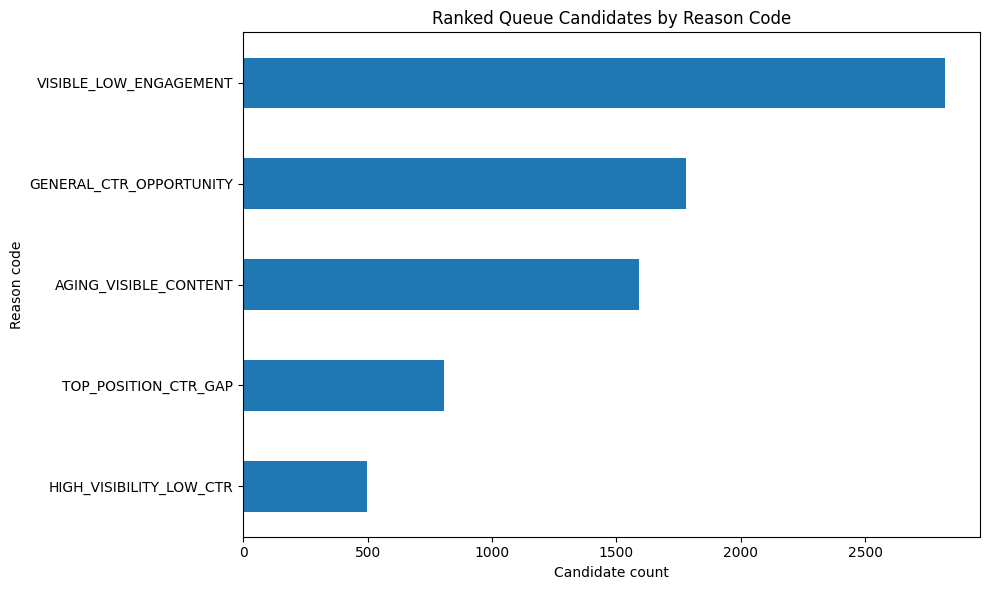

Figure created: work/figures/w07_reason_code_candidate_counts.png


In [37]:
# Figure 1 — Candidate count by reason code.

reason_count_figure = (
    ranked_queue["reason_code"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))
reason_count_figure.plot(kind="barh")

plt.title("Ranked Queue Candidates by Reason Code")
plt.xlabel("Candidate count")
plt.ylabel("Reason code")
plt.tight_layout()

REASON_FIGURE_PATH = (
    FIGURE_DIR / "w07_reason_code_candidate_counts.png"
)

plt.savefig(
    REASON_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Figure created:", REASON_FIGURE_PATH)

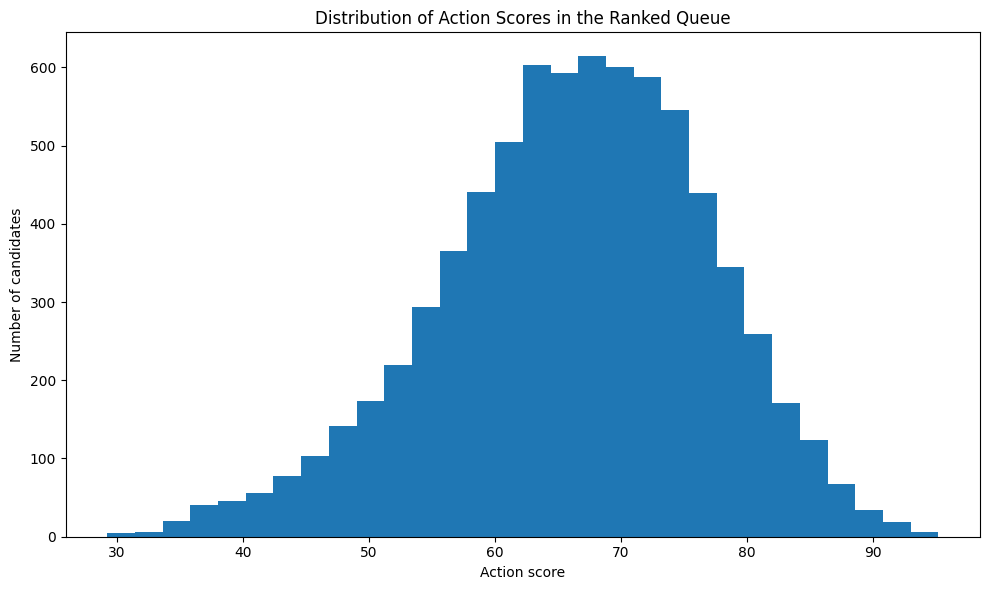

Figure created: work/figures/w07_action_score_distribution.png


In [38]:
# Figure 2 — Action-score distribution.

plt.figure(figsize=(10, 6))
plt.hist(
    ranked_queue["action_score"],
    bins=30,
)

plt.title("Distribution of Action Scores in the Ranked Queue")
plt.xlabel("Action score")
plt.ylabel("Number of candidates")
plt.tight_layout()

SCORE_FIGURE_PATH = (
    FIGURE_DIR / "w07_action_score_distribution.png"
)

plt.savefig(
    SCORE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Figure created:", SCORE_FIGURE_PATH)

In [39]:
# Confirm that all expected exports exist.

expected_exports = [
    QUEUE_PATH,
    METRICS_PATH,
    MONITORING_PATH,
    REASON_FIGURE_PATH,
    SCORE_FIGURE_PATH,
]

export_check = pd.DataFrame(
    {
        "file": [
            str(path)
            for path in expected_exports
        ],
        "exists": [
            path.exists()
            for path in expected_exports
        ],
        "size_bytes": [
            path.stat().st_size if path.exists() else 0
            for path in expected_exports
        ],
        "commit_to_git": [
            False,
            True,
            True,
            True,
            True,
        ],
    }
)

display(export_check)

if not export_check["exists"].all():
    raise FileNotFoundError(
        "One or more expected exports were not created."
    )

,file,exists,size_bytes,commit_to_git
0,work/outputs/w07_ranked_action_queue.csv,True,1736367,False
1,work/outputs/w07_action_playbook_metrics.json,True,1122,True
2,work/outputs/w07_monitoring_snapshot.json,True,428,True
3,work/figures/w07_reason_code_candidate_counts.png,True,76132,True
4,work/figures/w07_action_score_distribution.png,True,56958,True


### Export policy

The notebook generates the following paper-ready outputs:

| File                                                | Purpose                                                 | Git policy                              |
| --------------------------------------------------- | ------------------------------------------------------- | --------------------------------------- |
| `work/outputs/w07_ranked_action_queue.csv`          | Full ranked human-review queue                          | Regenerated locally and kept out of Git |
| `work/outputs/w07_action_playbook_metrics.json`     | Queue-size, score, reason-code, and evaluation receipts | Commit                                  |
| `work/outputs/w07_monitoring_snapshot.json`         | Lightweight monitoring reference for later runs         | Commit                                  |
| `work/figures/w07_reason_code_candidate_counts.png` | Paper-ready reason-code distribution figure             | Commit                                  |
| `work/figures/w07_action_score_distribution.png`    | Paper-ready action-score distribution figure            | Commit                                  |

The queue CSV contains anonymized identifiers and is created for analysis and paper preparation. It is not a production task list and does not authorize content changes.

The JSON files act as reproducibility receipts. They preserve the notebook’s main counts, assumptions, reference metrics, and monitoring values so that the next week’s paper can trace its reported numbers back to executed outputs.

The figures are descriptive. They show the composition and score distribution of the generated queue. They do not show causal impact, expected traffic gains, or business uplift.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [40]:
# Section 6 — Final reproducibility and privacy self-check.

from pathlib import Path
import json
import re

NOTEBOOK_PATH = Path("work/notebooks/w07_action_playbook.ipynb")

required_files = {
    "Notebook": NOTEBOOK_PATH,
    "Metrics JSON": Path("work/outputs/w07_action_playbook_metrics.json"),
    "Monitoring JSON": Path("work/outputs/w07_monitoring_snapshot.json"),
    "Reason-code figure": Path(
        "work/figures/w07_reason_code_candidate_counts.png"
    ),
    "Score-distribution figure": Path(
        "work/figures/w07_action_score_distribution.png"
    ),
}

self_check_results = pd.DataFrame(
    {
        "check": [
            f"{name} exists"
            for name in required_files
        ],
        "passed": [
            path.exists()
            for path in required_files.values()
        ],
        "path": [
            str(path)
            for path in required_files.values()
        ],
    }
)

display(self_check_results)

if not self_check_results["passed"].all():
    missing = self_check_results.loc[
        ~self_check_results["passed"],
        "path",
    ].tolist()

    raise FileNotFoundError(
        f"Missing required committed outputs: {missing}"
    )

print("All required notebook, JSON, and figure files exist.")

,check,passed,path
0,Notebook exists,True,work/notebooks/w07_action_playbook.ipynb
1,Metrics JSON exists,True,work/outputs/w07_action_playbook_metrics.json
2,Monitoring JSON exists,True,work/outputs/w07_monitoring_snapshot.json
3,Reason-code figure exists,True,work/figures/w07_reason_code_candidate_counts.png
4,Score-distribution figure exists,True,work/figures/w07_action_score_distribution.png


All required notebook, JSON, and figure files exist.


In [41]:
# Validate the ranked queue structure.

required_queue_columns = [
    "rank",
    "content_id",
    "client_id",
    "action_score",
    "review_priority",
    "reason_code",
    "content_archetype",
    "recommended_action",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
]

missing_queue_columns = [
    column
    for column in required_queue_columns
    if column not in queue_export.columns
]

if missing_queue_columns:
    raise ValueError(
        f"Queue export is missing columns: {missing_queue_columns}"
    )

assert len(queue_export) == len(ranked_queue)
assert queue_export["rank"].is_monotonic_increasing
assert queue_export["content_id"].notna().all()
assert queue_export["client_id"].notna().all()
assert queue_export["reason_code"].notna().all()
assert queue_export["recommended_action"].notna().all()
assert queue_export["action_score"].notna().all()

print(f"Queue rows validated: {len(queue_export):,}")
print("Queue ranks are ordered.")
print("Required queue fields are complete.")

Queue rows validated: 7,497
Queue ranks are ordered.
Required queue fields are complete.


In [42]:
# Check anonymization and avoid accidental URL or private-query exports.

identifier_checks = {
    "content_ids_are_anonymized": (
        queue_export["content_id"]
        .astype(str)
        .str.startswith("content_")
        .all()
    ),
    "client_ids_are_anonymized": (
        queue_export["client_id"]
        .astype(str)
        .str.startswith("client_")
        .all()
    ),
    "no_url_column_exported": not any(
        "url" in column.lower()
        for column in queue_export.columns
    ),
    "no_query_column_exported": not any(
        "query" in column.lower()
        for column in queue_export.columns
    ),
    "no_client_name_column_exported": not any(
        column.lower() in {
            "client_name",
            "company_name",
            "domain",
        }
        for column in queue_export.columns
    ),
}

privacy_check = pd.DataFrame(
    {
        "check": list(identifier_checks.keys()),
        "passed": list(identifier_checks.values()),
    }
)

display(privacy_check)

if not privacy_check["passed"].all():
    raise ValueError(
        "A privacy or anonymization check failed."
    )

print("Exported queue uses anonymized identifiers only.")
print("No URL, private-query, client-name, or domain column was exported.")

,check,passed
0,content_ids_are_anonymized,True
1,client_ids_are_anonymized,True
2,no_url_column_exported,True
3,no_query_column_exported,True
4,no_client_name_column_exported,True


Exported queue uses anonymized identifiers only.
No URL, private-query, client-name, or domain column was exported.


In [43]:
# Confirm key playbook requirements are represented.

reason_codes_present = set(
    ranked_queue["reason_code"].dropna().unique()
)

expected_reason_codes = {
    "HIGH_VISIBILITY_LOW_CTR",
    "TOP_POSITION_CTR_GAP",
    "AGING_VISIBLE_CONTENT",
    "VISIBLE_LOW_ENGAGEMENT",
    "GENERAL_CTR_OPPORTUNITY",
}

requirement_check = pd.DataFrame(
    [
        {
            "requirement": "Ranked queue created",
            "passed": len(ranked_queue) > 0,
        },
        {
            "requirement": "Reason codes assigned",
            "passed": expected_reason_codes.issubset(
                reason_codes_present
            ),
        },
        {
            "requirement": "Archetype-to-action mapping created",
            "passed": (
                ranked_queue["content_archetype"].notna().all()
                and ranked_queue["recommended_action"].notna().all()
            ),
        },
        {
            "requirement": "Decay/refresh group represented",
            "passed": (
                ranked_queue["reason_code"]
                .eq("AGING_VISIBLE_CONTENT")
                .any()
            ),
        },
        {
            "requirement": "Human-review rules documented",
            "passed": len(human_review_rules) >= 5,
        },
        {
            "requirement": "No-go cases documented",
            "passed": len(no_go_cases) >= 5,
        },
        {
            "requirement": "Monitoring triggers documented",
            "passed": len(monitoring_plan) >= 5,
        },
        {
            "requirement": "Queue CSV regenerated",
            "passed": QUEUE_PATH.exists(),
        },
        {
            "requirement": "Metrics receipts exported",
            "passed": (
                METRICS_PATH.exists()
                and MONITORING_PATH.exists()
            ),
        },
        {
            "requirement": "Reusable figures exported",
            "passed": (
                REASON_FIGURE_PATH.exists()
                and SCORE_FIGURE_PATH.exists()
            ),
        },
    ]
)

display(requirement_check)

if not requirement_check["passed"].all():
    failed_requirements = requirement_check.loc[
        ~requirement_check["passed"],
        "requirement",
    ].tolist()

    raise AssertionError(
        f"Self-check failed: {failed_requirements}"
    )

print("All playbook requirements passed the notebook self-check.")

,requirement,passed
0,Ranked queue created,True
1,Reason codes assigned,True
2,Archetype-to-action mapping created,True
3,Decay/refresh group represented,True
4,Human-review rules documented,True
5,No-go cases documented,True
6,Monitoring triggers documented,True
7,Queue CSV regenerated,True
8,Metrics receipts exported,True
9,Reusable figures exported,True


All playbook requirements passed the notebook self-check.


### Final submission check

Before submission, I confirmed the following honestly:

* [x] Every required section contains both written interpretation and supporting code.
* [x] The notebook runs from top to bottom without errors using **Runtime → Run all**.
* [x] The queue contains anonymized `content_id` and `client_id` values only.
* [x] No client names, domains, page URLs, or private search queries are exported.
* [x] The notebook uses careful terms such as **observed**, **measured**, **directional**, **prioritization**, and **decision-support**.
* [x] The notebook clearly states that the recommendations do not prove causal traffic, ranking, conversion, revenue, or business improvement.
* [x] The notebook clearly states that content editing, publishing, deletion, redirection, deindexing, and retraining must not be automated.
* [x] The ranked queue CSV is regenerated under `work/outputs/` and is not intended to be committed.
* [x] The metrics and monitoring JSON receipts are generated under `work/outputs/`.
* [x] Reusable figures are generated under `work/figures/`.
* [x] The executed notebook, JSON receipts, and figures have been committed to the repository.

The two unchecked items must only be marked complete after running the entire notebook without errors and committing the required files.
